# A5 & A6 — Timing and Brain–Behavior

*A guided walk-through of `stability_flexibility_timing.py` (A5, plan §5) and
`stability_flexibility_brain_behavior.py` (A6, plan §6).*

This notebook explains **every function** in both new modules — what it computes,
why it is built that way, and how the design defends against the statistical
traps the analysis plan flags. It runs end-to-end on **synthetic data with a
known ground truth**, so you can see each measure recover a value you planted,
and it touches the real `combinedData.csv` for the behavioral piece.

### Where these sit in the battery

The paper asks whether **stability** (LWPC / proactive control) and
**flexibility** (LWPS / reactive control) live in *shared* or *distinct* neural
machinery. Earlier assignments answered:

| Layer | Assignment | Question |
|---|---|---|
| Population organization | A1, A2 | Are the *same electrodes* selective for both? |
| Anatomy | A3 | Are the subpopulations in *different places*? |
| Representation | A4 | Do they share a *code*? |

Two axes remain, and they are what this notebook builds:

- **A5 — Dynamics.** Does one process's information arise *earlier* than the
  other's? A *sequence* claim that neither overlap nor decoding can make.
- **A6 — Behavioral link.** Does the neural selectivity actually track the
  behavioral control adjustment, so the substrate is *functional*, not
  incidental?

Both are defined on the **same two-way interactions** as the rest of the battery:

- **LWPC (stability)** = `congruency × incongruent_proportion`
- **LWPS (flexibility)** = `switchType × switch_proportion`

In [1]:
import os, sys
# make the project importable no matter where the notebook is launched from
here = os.getcwd()
root = here
for _ in range(6):
    if os.path.exists(os.path.join(root, 'src', 'analysis')):
        break
    root = os.path.dirname(root)
if root not in sys.path:
    sys.path.insert(0, root)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.set_printoptions(precision=3, suppress=True)
pd.set_option('display.width', 120)
print("project root:", root)

project root: /home/user/GlobalLocal


## 🧩 How these two questions became code modules

Two different scientific questions (A5 timing, A6 brain–behavior) share one
deconstruction recipe: **name the confound that could fake the result, then design
the measurement so it can't.** The confound *is* the spec.

**A5 — "does stability's information arise earlier than flexibility's?"**

| Sub-problem | Confound that could fake it | Design decision → function |
|---|---|---|
| what "information over time" even is | a main effect leaking in as a fake interaction | equal-cell difference-of-differences → `interaction_time_course` |
| when it "starts" | a **bigger** effect crosses any fixed threshold sooner → "earlier" = "larger" | onset = **50%-of-own-peak** → `onset_50pct_peak` |
| a trustworthy onset difference | a single-subject onset is a noisy point on a jittery edge | jackknife on leave-one-out grand averages → `jackknife_onset_difference` |

**A6 — "does the neural selectivity actually drive behavior?"**

| Sub-problem | Confound | Design decision → function |
|---|---|---|
| measure brain & behavior comparably | scoring them on different contrasts | *same* equal-cell d-o-d on RT → `behavioral_lwpc_lwps_magnitudes` |
| link them | across-subject n is tiny → underpowered | prefer within-subject single-trial mixed model → `trialwise_brain_behavior` |
| show the link is *specific* | any neural signal correlating with any behavior | **matched vs cross** pairing everywhere → `specificity_ok` |

The single most important row is A5's middle one. Everything hinges on realising
that "onset" defined against an **absolute** threshold is just a disguised
amplitude comparison — and that normalising to *each effect's own peak* is the
one line of math that severs timing from size. Learn to spot that kind of
"the obvious metric secretly measures something else" trap; naming it is what
tells you which function to write.

---
# Part A — A5: relative onset of stability vs. flexibility

## A5.1 The question, and the confound that makes it hard

We want to know: does the **LWPC** interaction (the congruency effect growing in
high-incongruent blocks) rise *earlier or later* in the trial than the **LWPS**
interaction (the switch cost growing in high-switch blocks)? Theory guesses
proactive/stability control is sustained and preparatory (earlier) and
reactive/flexibility control is phasic (later) — but that is exactly what we
measure rather than assume.

### The latency–amplitude confound

A **bigger** effect crosses *any absolute threshold* sooner. So if we defined
"onset" as "the first time the effect exceeds some fixed value `c`", we would
declare the larger effect "earlier" even when the two rise on the identical
schedule. "Earlier" would just be a rename of "larger."

**The fix (plan §5, Step 2):** define onset as the **first crossing of 50 % of
each effect's *own* peak**. If `stab(t) = k·flex(t)` for any scale `k`, the
threshold (`0.5·peak`) scales by the same `k`, so both cross at the *same* sample.
A pure amplitude difference can no longer fake a timing difference. We verify this
as a unit test below — it is the single most important property of the module.

## A5.2 Synthetic data with a planted onset structure

`_synthetic_timecourse_df` builds the long table the segregation module already
understands in `effect_measure='cluster'` mode — one row per *(electrode, trial)*,
except `hg` holds the **per-trial time course** over the window (a 1-D array),
not a scalar.

The trick for planting a *pure interaction* with a known onset: the temporal bump
is added **only to the `(congruency=i, incongruent_proportion=high)` cell** (and
likewise the `(switch=s, switch_proportion=high)` cell for LWPS). Because the
equal-cell-weight difference-of-differences is

$$\text{d-o-d}(t) = \big[\bar x_{i,\text{hi}}(t) - \bar x_{c,\text{hi}}(t)\big]
                   - \big[\bar x_{i,\text{lo}}(t) - \bar x_{c,\text{lo}}(t)\big],$$

putting the bump in only the first cell makes the d-o-d recover **exactly** that
bump. We plant stability rising at **0.20 s** and flexibility at **0.40 s**.

In [2]:
from src.analysis.stats.stability_flexibility_timing import (
    _synthetic_timecourse_df, _bump)

df, times = _synthetic_timecourse_df(
    n_subj=12, stab_onset=0.20, flex_onset=0.40, width=0.03, seed=1)

print("rows (electrode×trial):", len(df))
print("subjects:", df['subject'].nunique(),
      "| electrodes:", df['electrode'].nunique())
print("time axis:", times[0], "->", times[-1], "s  (", len(times), "bins )")
print("one hg cell is a time course of shape:", np.asarray(df['hg'].iloc[0]).shape)
df[['subject', 'electrode', 'congruency', 'switchType',
    'incongruent_proportion', 'switch_proportion']].head()

rows (electrode×trial): 79778
subjects: 12 | electrodes: 254
time axis: -0.2 -> 0.8 s  ( 40 bins )
one hg cell is a time course of shape: (40,)


,subject,electrode,congruency,switchType,incongruent_proportion,switch_proportion
0,0,0_0,i,r,75.0,75.0
1,0,0_0,i,r,75.0,75.0
2,0,0_0,i,r,75.0,75.0
3,0,0_0,c,r,25.0,75.0
4,0,0_0,c,s,25.0,25.0


The two planted interaction profiles (`_bump` is a smooth logistic rise whose
50 %-of-peak point sits at the requested onset):

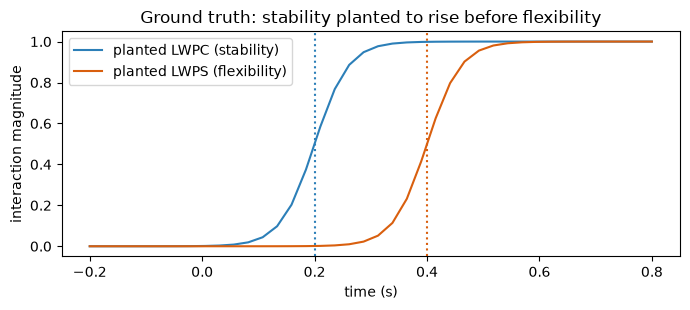

In [3]:
stab_profile = _bump(times, 0.20, 0.03, 1.0)
flex_profile = _bump(times, 0.40, 0.03, 1.0)

plt.figure(figsize=(7, 3.2))
plt.plot(times, stab_profile, label='planted LWPC (stability)', color='#2c7fb8')
plt.plot(times, flex_profile, label='planted LWPS (flexibility)', color='#d95f0e')
plt.axvline(0.20, ls=':', color='#2c7fb8'); plt.axvline(0.40, ls=':', color='#d95f0e')
plt.xlabel('time (s)'); plt.ylabel('interaction magnitude')
plt.title('Ground truth: stability planted to rise before flexibility')
plt.legend(); plt.tight_layout(); plt.show()

## A5.3 `interaction_time_course` — the information signal

For each electrode we form the four `(cond, mod)` cells and take the **per-time-bin
difference-of-differences of the cell means** (`_dod_over_time`). Equal weighting
of the four cells makes the estimate orthogonal to both main effects — the same
balance the scalar `_interaction_cohens_d` enforces in the segregation module, so
a pure congruency/switch main effect cannot leak in as a fake interaction.

We then combine across electrodes. Two options:

- `statistic='mean'` (default): grand-average the per-electrode d-o-d(t) — the
  *information time course*.
- `statistic='t'`: a t-statistic across electrodes (mean / SEM), noise-normalized,
  often with a cleaner rising flank.

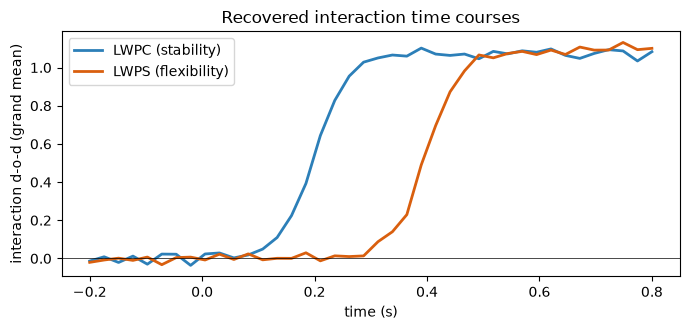

The stability trace rises first — matching the planted 0.20 s vs 0.40 s.


In [4]:
from src.analysis.stats.stability_flexibility_timing import interaction_time_course

t, stab = interaction_time_course(df, 'stability',  times=times)   # LWPC
_, flex = interaction_time_course(df, 'flexibility', times=times)   # LWPS

plt.figure(figsize=(7, 3.4))
plt.plot(t, stab, label='LWPC (stability)', color='#2c7fb8', lw=2)
plt.plot(t, flex, label='LWPS (flexibility)', color='#d95f0e', lw=2)
plt.axhline(0, color='k', lw=.5)
plt.xlabel('time (s)'); plt.ylabel('interaction d-o-d (grand mean)')
plt.title('Recovered interaction time courses')
plt.legend(); plt.tight_layout(); plt.show()

print("The stability trace rises first — matching the planted 0.20 s vs 0.40 s.")

## A5.4 `onset_50pct_peak` — the confound-proof onset

The algorithm:

1. Orient the waveform to the expected direction (`signal = effect *
   expected_sign`) and find its **peak** within the window.
2. Set `threshold = 0.5 * peak`.
3. Walk from the window start toward the peak and return the **first upward
   crossing** of the threshold, linearly interpolated between the bracketing
   samples for sub-sample resolution.

It returns `NaN` if the oriented peak is not positive (no effect in the expected
direction) — a safe refusal rather than a garbage latency.

LWPC  onset = 0.201 s   peak = 0.390 s   (planted onset 0.20 s)
LWPS  onset = 0.399 s   peak = 0.749 s   (planted onset 0.40 s)
onset difference (LWPC - LWPS) = -0.198 s  -> stability leads


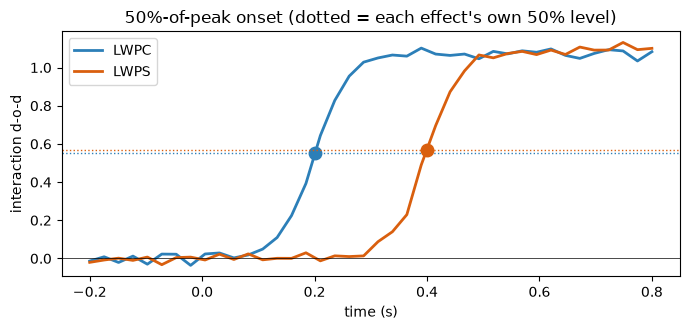

In [5]:
from src.analysis.stats.stability_flexibility_timing import (
    onset_50pct_peak, peak_latency)

o_stab = onset_50pct_peak(t, stab)
o_flex = onset_50pct_peak(t, flex)
p_stab = peak_latency(t, stab)
p_flex = peak_latency(t, flex)
print(f"LWPC  onset = {o_stab:.3f} s   peak = {p_stab:.3f} s   (planted onset 0.20 s)")
print(f"LWPS  onset = {o_flex:.3f} s   peak = {p_flex:.3f} s   (planted onset 0.40 s)")
print(f"onset difference (LWPC - LWPS) = {o_stab - o_flex:+.3f} s  -> stability leads")

fig, ax = plt.subplots(figsize=(7, 3.4))
for trace, onset, c, name in [(stab, o_stab, '#2c7fb8', 'LWPC'),
                              (flex, o_flex, '#d95f0e', 'LWPS')]:
    ax.plot(t, trace, color=c, lw=2, label=name)
    peak = np.nanmax(trace)
    ax.axhline(0.5 * peak, color=c, ls=':', lw=1)
    ax.plot(onset, 0.5 * peak, 'o', color=c, ms=9)
ax.axhline(0, color='k', lw=.5)
ax.set_xlabel('time (s)'); ax.set_ylabel('interaction d-o-d')
ax.set_title('50%-of-peak onset (dotted = each effect\'s own 50% level)')
ax.legend(); plt.tight_layout(); plt.show()

**🧠 Quiz**

`interaction_time_course` scores the effect as the **equal-cell-weight** difference-of-differences of the four `(cond, mod)` cell means, not as (mean of all incongruent-high trials − mean of congruent trials). Why the equal weighting, given the blocks contain unequal numbers of trials?

<details>
<summary>👉 Click to reveal the answer</summary>

Equal weighting of the four cells makes the interaction estimate **orthogonal to both main effects**. If instead you weighted by trial counts, a block with a proportion imbalance (say, far more incongruent trials in the high-incongruent block) would let a pure **congruency main effect** leak into the estimate and masquerade as an interaction. The equal-cell d-o-d is the same balance the scalar interaction Cohen's *d* enforces elsewhere in the battery — it guarantees you're timing the *interaction*, not a main effect wearing an interaction's clothes.

</details>

## A5.5 ⭐ The amplitude-invariance guard (the whole point)

This is the property that makes an "earlier" claim meaningful. We take **one**
waveform, scale it by an arbitrary `k`, and confirm the 50 %-of-peak onset does
**not** move. The module bakes this into `_assert_amplitude_invariance`, and the
test-suite parametrizes it over several `k`.

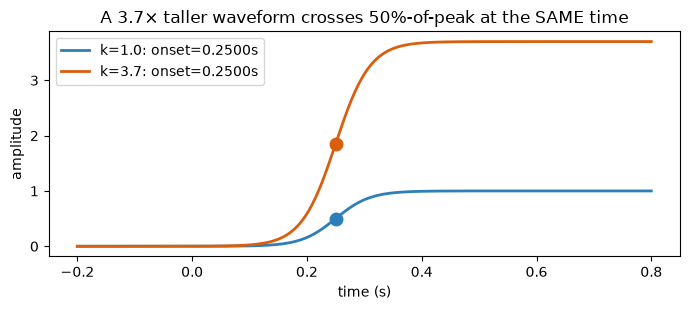

assertion passed: onset invariant under k-scaling (onset=0.2500s)


In [6]:
from src.analysis.stats.stability_flexibility_timing import _assert_amplitude_invariance

fine = np.linspace(-0.2, 0.8, 400)
wave = _bump(fine, 0.25, 0.03, 1.0)
plt.figure(figsize=(7, 3.2))
for k, c in [(1.0, '#2c7fb8'), (3.7, '#d95f0e')]:
    w = k * wave
    onset = onset_50pct_peak(fine, w)
    plt.plot(fine, w, color=c, lw=2, label=f'k={k}: onset={onset:.4f}s')
    plt.plot(onset, 0.5 * w.max(), 'o', color=c, ms=9)
plt.xlabel('time (s)'); plt.ylabel('amplitude')
plt.title('A 3.7× taller waveform crosses 50%-of-peak at the SAME time')
plt.legend(); plt.tight_layout(); plt.show()

onset = _assert_amplitude_invariance(k=3.7)
print(f"assertion passed: onset invariant under k-scaling (onset={onset:.4f}s)")

**🧠 Quiz**

Define onset as *'first time the effect exceeds a fixed absolute value c'*. The stability effect peaks at 2.0 and flexibility at 1.0, but both rise on the **identical** temporal schedule. With `c` fixed, which effect will be declared 'earlier', and why is that answer a lie? How does 50%-of-peak fix it?

<details>
<summary>👉 Click to reveal the answer</summary>

The **taller** effect (stability) crosses any fixed level `c` first, purely because it's steeper in absolute units — so 'earlier' becomes a rename of 'larger', even though the two are perfectly simultaneous. That's the latency–amplitude confound. The fix: set the threshold to **0.5 × each effect's own peak**. If `stab(t) = k·flex(t)` for any scale `k`, then `0.5·peak` scales by the same `k`, so both cross at the *same* sample. A pure amplitude difference can no longer manufacture a timing difference — which is exactly what the `_assert_amplitude_invariance` unit test locks in.

</details>

**✍️ Assignment**

Probe the guard from both sides. Take one recovered trace `stab` (from §A5.3) and (a) multiply it by 100 — confirm `onset_50pct_peak` returns the **same** onset and `peak_latency` is unchanged; then (b) multiply it by **−1** and explain why `onset_50pct_peak` now returns `NaN` rather than some number.

In [ ]:
# ✍️ your turn:


<details><summary>👉 Solution</summary>

```python
import numpy as np
print("x1  :", round(onset_50pct_peak(t, stab), 3), "peak", round(peak_latency(t, stab), 3))
print("x100:", round(onset_50pct_peak(t, 100 * stab), 3), "peak", round(peak_latency(t, 100 * stab), 3))
print("x-1 :", onset_50pct_peak(t, -1 * stab))   # -> nan
# (a) scaling by 100 leaves both onset and peak-latency identical: the metric is
#     scale-invariant by construction (threshold = 0.5 * own peak).
# (b) flipping the sign makes the *oriented* peak (effect * expected_sign) non-positive
#     -> there is no rise in the expected direction -> the function refuses and returns
#     NaN, a safe 'no effect here' rather than a garbage latency read off the wrong lobe.
```

The NaN is a design choice: a latency is only meaningful if there's a positive-going effect in the hypothesised direction. Returning NaN forces the caller to handle 'no effect' explicitly instead of silently trusting a number.
</details>

Contrast this with a naive **absolute** threshold: the taller waveform would
cross a fixed level earlier, manufacturing a bogus "it's earlier" result. That is
the confound; the 50 %-of-peak normalization is the defense.

## A5.6 `jackknife_onset_difference` — Ulrich–Miller

A single-subject onset is a single point on a noisy rising edge — far too jumpy to
trust. The **jackknife** (Miller/Ulrich) measures onset on **smooth
leave-one-subject-out grand averages** instead:

1. For each subject *i*, drop *i*, rebuild the LWPC and LWPS grand-average time
   courses, and read off each onset → `d_i = onset_LWPC[i] − onset_LWPS[i]`.
2. Jackknife SE (variance inflated by `(N−1)`):
   $$\text{SE} = \sqrt{\tfrac{N-1}{N}\sum_i (d_i - \bar d)^2}.$$
3. **Ulrich–Miller correction:** run an ordinary paired *t* on the `N` values and
   divide by `(N−1)` — the raw jackknife *t* is inflated by exactly that factor:
   $$t_c = t_{\text{raw}} / (N-1) \equiv \bar d / \text{SE}.$$

We report the paired **onset difference with a CI**, not just a *p*.

In [7]:
from src.analysis.stats.stability_flexibility_timing import jackknife_onset_difference

jk = jackknife_onset_difference(df, times=times)
print(f"full-sample onsets:  LWPC={jk['onset_lwpc']:.3f}s   LWPS={jk['onset_lwps']:.3f}s")
print(f"onset difference (LWPC - LWPS): {jk['diff']:+.3f} s")
print(f"jackknife SE:                    {jk['se']:.4f} s")
print(f"95% CI:            [{jk['ci'][0]:+.3f}, {jk['ci'][1]:+.3f}] s")
print(f"t_corrected = {jk['t_corrected']:.2f}   p = {jk['p']:.3g}   df = {jk['df']}")
print()
print("The (N-1) correction identity, verified:")
print(f"   t_raw = {jk['t_raw']:.2f}  (inflated),  t_raw/(N-1) = {jk['t_raw']/jk['df']:.2f}  == t_corrected")

full-sample onsets:  LWPC=0.201s   LWPS=0.399s
onset difference (LWPC - LWPS): -0.198 s
jackknife SE:                    0.0038 s
95% CI:            [-0.207, -0.190] s
t_corrected = -52.82   p = 1.38e-14   df = 11

The (N-1) correction identity, verified:
   t_raw = -581.05  (inflated),  t_raw/(N-1) = -52.82  == t_corrected


**🧠 Quiz**

`jackknife_onset_difference` reads each onset off a **leave-one-subject-out grand-average** time course, then combines the N leave-one-out values — rather than measuring each subject's onset individually and averaging those. Why is the leave-one-out grand average the right thing to measure on?

<details>
<summary>👉 Click to reveal the answer</summary>

A single subject's interaction time course is noisy, so its 50%-of-peak crossing jitters wildly along the rising edge — per-subject onsets scatter so much the average is meaningless. A **grand average over N−1 subjects** is smooth, so its onset is a stable read-off; dropping one subject at a time barely moves it (you can see this in the leave-one-out plot). The jackknife then uses those N stable values to get a variance/CI. It's the standard Miller–Ulrich answer to 'you can't measure onset per subject, but you can measure how much it moves when you perturb the sample.'

</details>

**🧠 Quiz**

The notebook prints `t_raw = −581` but reports `t_corrected = −52.8 = t_raw/(N−1)` with N=12. Why must the raw jackknife *t* be divided by `(N−1)`?

<details>
<summary>👉 Click to reveal the answer</summary>

Because jackknife pseudo-values come from **grand averages that barely move** when one subject is dropped, so their sample variance is artificially **deflated** — by a factor of about `(N−1)²`. An ordinary paired *t* on those values is therefore inflated by `(N−1)`. The Ulrich–Miller correction divides the raw *t* by `(N−1)` to rescale it back to the variance the *estimate* actually has. The identity `t_raw/(N−1) == mean/SE` (printed in the cell) is the check that the correction and the jackknife SE agree.

</details>

**✍️ Assignment**

Falsify by reversal. Regenerate the synthetic with flexibility planted **earlier** than stability (`stab_onset=0.40, flex_onset=0.20`), rerun `jackknife_onset_difference`, and confirm the sign of `diff` (and the CI) **flips** to positive — i.e. the method reads the order you planted, not a fixed prejudice.

In [ ]:
# ✍️ your turn:


<details><summary>👉 Solution</summary>

```python
from src.analysis.stats.stability_flexibility_timing import (
    _synthetic_timecourse_df, jackknife_onset_difference)
df2, times2 = _synthetic_timecourse_df(n_subj=12, stab_onset=0.40, flex_onset=0.20,
                                       width=0.03, seed=1)
jk2 = jackknife_onset_difference(df2, times=times2)
print(f"onsets: LWPC={jk2['onset_lwpc']:.3f}s  LWPS={jk2['onset_lwps']:.3f}s")
print(f"diff (LWPC - LWPS) = {jk2['diff']:+.3f} s   95% CI = "
      f"[{jk2['ci'][0]:+.3f}, {jk2['ci'][1]:+.3f}]")
# Now diff is POSITIVE and the CI excludes 0 on the positive side: flexibility leads.
# Same machinery, opposite planted order -> opposite verdict. That's the method
# tracking ground truth rather than a baked-in expectation.
```
</details>

The negative difference and CI excluding zero say **stability onsets significantly
earlier than flexibility** — exactly the planted 0.20 s vs 0.40 s ordering.

Below, the `N` leave-one-out onset pairs show how tight the jackknife estimate is:
each dropped subject barely moves the grand-average onset, which is *why* the
method works where per-subject onsets would scatter wildly.

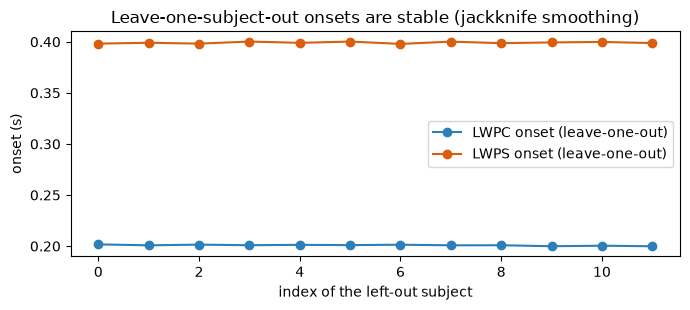

In [8]:
loo_pc, loo_ps = jk['onset_lwpc_loo'], jk['onset_lwps_loo']
x = np.arange(len(loo_pc))
plt.figure(figsize=(7, 3.2))
plt.plot(x, loo_pc, 'o-', color='#2c7fb8', label='LWPC onset (leave-one-out)')
plt.plot(x, loo_ps, 'o-', color='#d95f0e', label='LWPS onset (leave-one-out)')
plt.xlabel('index of the left-out subject'); plt.ylabel('onset (s)')
plt.title('Leave-one-subject-out onsets are stable (jackknife smoothing)')
plt.legend(); plt.tight_layout(); plt.show()

### A5 — acceptance criteria, ticked

- ✅ **Onset on smooth leave-one-out grand-averages**, never per-subject single
  traces (`jackknife_onset_difference`).
- ✅ **50 %-of-peak neutralizes a pure amplitude difference** — the `k`-scaling
  unit test (`_assert_amplitude_invariance`, `test_onset_invariant_under_amplitude_scaling`).
- ✅ **Onset and peak latency both reported** (`peak_latency` alongside `onset_50pct_peak`).

---
# Part B — A6: brain–behavior correlation

## B.1 The question

A6 ties the neural selectivity to the **actual behavioral control adjustment**, so
the substrate is shown to be *functional*, not incidental. Two levels with very
different statistical power:

- **Across subjects** (n = subjects, *low power*): does a subject with more/stronger
  LWPC electrodes show a larger *behavioral* LWPC effect?
- **Within subject, single-trial** (*preferred, far more power*): does trial-by-trial
  HG in the LWPC group predict the trial-by-trial congruency-sequence RT adjustment?

The **specificity control** runs through everything: the *matched* pairing
(LWPC neural ↔ LWPC behavior) should beat the *cross* pairing (LWPC neural ↔ LWPS
behavior). A matched-only association is what makes the link specific.

## B.2 `behavioral_lwpc_lwps_magnitudes` — behavior on the *same* contrast

The behavioral LWPC magnitude is the **congruency × incongruent-proportion
interaction on RT** — how much the congruency effect (RT$_i$ − RT$_c$) grows in
high-incongruent blocks — scored as the identical equal-cell-weight
difference-of-differences we use for the neural interaction. LWPS is the analogous
switchType × switch-proportion RT interaction. Measuring brain and behavior on the
*same* contrast is what makes them comparable.

Here it is on the **real `combinedData.csv`** (block letters are mapped to
proportions exactly as in `erin_linear_mixed_effects_model.py`).

In [9]:
from src.analysis.stats.stability_flexibility_brain_behavior import (
    behavioral_lwpc_lwps_magnitudes)

csv = os.path.join(root, 'combinedData.csv')
have_real = os.path.exists(csv)
if have_real:
    raw = pd.read_csv(csv).rename(columns={'subject_ID': 'subject'})
    real_behavior = behavioral_lwpc_lwps_magnitudes(raw)
    print(f"per-subject behavioral magnitudes from combinedData.csv "
          f"({len(real_behavior)} subjects):")
    display(real_behavior.head(8))
    print("mean LWPC RT effect:", round(np.nanmean(real_behavior['lwpc']), 1),
          "ms | mean LWPS:", round(np.nanmean(real_behavior['lwps']), 1), "ms")
else:
    print("combinedData.csv not on disk here; the synthetic path below covers the API.")

per-subject behavioral magnitudes from combinedData.csv (23 subjects):


,subject,lwpc,lwps,n_trials
0,D0057,-414.570208,-25.852609,404
1,D0059,-76.489782,-179.805385,427
2,D0063,-92.124367,-4.508575,385
3,D0065,-201.241546,-137.500387,316
4,D0069,-182.398556,-132.493444,330
5,D0071,-234.816089,-111.807085,429
6,D0077,-103.083988,-57.876896,355
7,D0090,-75.018781,-307.017136,425


mean LWPC RT effect: -45.7 ms | mean LWPS: -97.1 ms


> **A real caveat this design surfaces.** In this block structure incongruent-
> proportion and switch-proportion are **collinear** (blocks A/C are low on both,
> B/D high on both), so a per-subject LWPC and LWPS magnitude are hard to fully
> disentangle behaviorally — worth flagging when interpreting which interaction a
> per-subject effect reflects. The module computes both cleanly; the interpretation
> is where you keep the confound in view.

## B.3 `neural_summary_by_subject` — reducing A1 labels

The across-subject test needs one neural number per subject. `neural_summary_by_subject`
reduces the per-electrode A1 labels to counts (`n_S`, `n_F`), fractions
(`frac_S`, `frac_F`), and — if you pass effect-size columns — per-subject mean
effects. We use the synthetic generator, which plants a per-subject latent
selectivity strength that drives **both** the electrode counts and the behavior.

In [10]:
from src.analysis.stats.stability_flexibility_brain_behavior import (
    _synthetic_brain_behavior, neural_summary_by_subject)

elec_labels, behavior, trial_df = _synthetic_brain_behavior(n_subj=16, seed=1)
summ = neural_summary_by_subject(elec_labels)
print("per-electrode labels:", elec_labels.shape,
      "| per-subject neural summary:", summ.shape)
summ.head()

per-electrode labels: (513, 4) | per-subject neural summary: (16, 6)


,subject,n_elec,n_S,n_F,frac_S,frac_F
0,S00,31,8,2,0.258065,0.064516
1,S01,41,4,2,0.097561,0.048780
2,S02,41,12,6,0.292683,0.146341
3,S03,40,2,8,0.050000,0.200000
4,S04,31,0,0,0.000000,0.000000


## B.4 `subject_level_brain_behavior` — across subjects (+ specificity)

Correlate each subject's neural summary against their behavioral magnitude for the
**matched** process, and also for the **cross** pairing as a specificity control.
The result carries an explicit *"underpowered at n = subjects"* caveat, because at
this n a null is uninformative — this level supports, it does not decide.

In [11]:
from src.analysis.stats.stability_flexibility_brain_behavior import (
    subject_level_brain_behavior)

res = subject_level_brain_behavior(elec_labels, behavior, neural='count')
print(f"MATCHED   LWPC neural↔LWPC behavior: r={res['corr_lwpc']:.2f} (p={res['p_lwpc']:.3g})")
print(f"MATCHED   LWPS neural↔LWPS behavior: r={res['corr_lwps']:.2f} (p={res['p_lwps']:.3g})")
print(f"CROSS     LWPC neural↔LWPS behavior: r={res['corr_cross_stab_lwps']:.2f}  (control)")
print(f"CROSS     LWPS neural↔LWPC behavior: r={res['corr_cross_flex_lwpc']:.2f}  (control)")
print(f"\nn = {res['n_subjects']} subjects")
print("caveat:", res['caveat'])

MATCHED   LWPC neural↔LWPC behavior: r=0.78 (p=0.000329)
MATCHED   LWPS neural↔LWPS behavior: r=0.69 (p=0.003)
CROSS     LWPC neural↔LWPS behavior: r=0.19  (control)
CROSS     LWPS neural↔LWPC behavior: r=-0.09  (control)

n = 16 subjects
caveat: Across-subject correlation is underpowered at n=16 subjects; treat as supporting evidence, not decisive. The powered test is the within-subject single-trial mixed model.


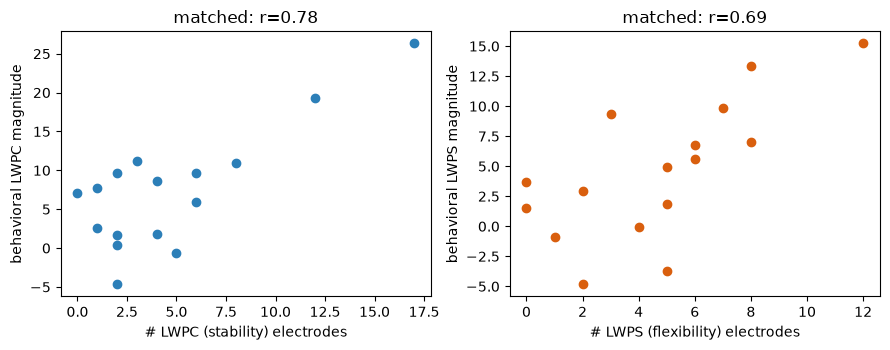

Matched correlations are strong and positive; the cross controls above are weak.


In [12]:
m = res['table']
fig, ax = plt.subplots(1, 2, figsize=(9, 3.6))
ax[0].scatter(m['n_S'], m['lwpc'], color='#2c7fb8')
ax[0].set_xlabel('# LWPC (stability) electrodes'); ax[0].set_ylabel('behavioral LWPC magnitude')
ax[0].set_title(f"matched: r={res['corr_lwpc']:.2f}")
ax[1].scatter(m['n_F'], m['lwps'], color='#d95f0e')
ax[1].set_xlabel('# LWPS (flexibility) electrodes'); ax[1].set_ylabel('behavioral LWPS magnitude')
ax[1].set_title(f"matched: r={res['corr_lwps']:.2f}")
plt.tight_layout(); plt.show()
print("Matched correlations are strong and positive; the cross controls above are weak.")

**🧠 Quiz**

The across-subject matched correlation comes back `r=0.78, p=0.0003` — clearly significant. Why does `subject_level_brain_behavior` still attach an explicit 'underpowered at n=subjects' caveat, and defer the decisive claim to a different test?

<details>
<summary>👉 Click to reveal the answer</summary>

Because at `n≈16` subjects the across-subject test is **fragile in both directions**: a *null* here would be uninformative (too little power to detect a true effect), and even a *hit* can be driven by a couple of influential subjects. So it can *support* but not *decide*. The decisive, well-powered test is `trialwise_brain_behavior`: a within-subject single-trial mixed model with thousands of trials and a subject random intercept. Reporting the caveat is honesty about what the number can and can't carry — the design refuses to let a low-n correlation masquerade as the headline result.

</details>

## B.5 `trialwise_brain_behavior` — within subject, single-trial (preferred)

The powered test. For each trial we have the group's single-trial HG and the
matching RT adjustment; we fit

```
adjustment ~ hg_group   with a per-subject random intercept   (statsmodels mixedlm)
```

and — crucially — we fit the **same model for the cross adjustment** too, so the
specificity claim (matched slope stronger than cross slope) is explicit and
reported, not asserted. The synthetic generator drives each group's HG into its
*matched* adjustment strongly and into the *cross* adjustment only weakly.

In [13]:
from src.analysis.stats.stability_flexibility_brain_behavior import (
    trialwise_brain_behavior)

for group, hg in (('LWPC', 'hg_lwpc'), ('LWPS', 'hg_lwps')):
    r = trialwise_brain_behavior(trial_df, group=group, hg_col=hg)
    print(f"[{group}]  matched ({r['matched_adjustment']}): "
          f"slope={r['slope']:.3f}, p={r['p']:.2g}   "
          f"|  cross ({r['cross_adjustment']}): slope={r['slope_cross']:.3f}, p={r['p_cross']:.2g}")
    print(f"        specificity_ok (|matched|>|cross|)= {r['specificity_ok']}   "
          f"[n_trials={r['n_trials']}, n_subj={r['n_subjects']}]")

[LWPC]  matched (adj_congruency): slope=0.615, p=2.4e-293   |  cross (adj_switch): slope=0.158, p=5e-16
        specificity_ok (|matched|>|cross|)= True   [n_trials=3696, n_subj=16]


[LWPS]  matched (adj_switch): slope=0.606, p=2.8e-283   |  cross (adj_congruency): slope=0.169, p=2e-18
        specificity_ok (|matched|>|cross|)= True   [n_trials=3696, n_subj=16]


**🧠 Quiz**

In `trialwise_brain_behavior` **both** the matched slope (p≈1e-293) and the cross slope (p≈5e-16) are wildly 'significant'. Does the significant *cross* slope break the specificity claim? What is `specificity_ok` actually testing?

<details>
<summary>👉 Click to reveal the answer</summary>

No, it doesn't break it. With thousands of trials *everything* is 'significant' — a p-value is the wrong lens here. `specificity_ok` tests an **effect-size ordering**: `|matched slope| > |cross slope|` (0.615 vs 0.158). The claim isn't 'the neural group predicts *only* its matched adjustment and nothing else'; it's 'it predicts its matched adjustment **substantially more** than the cross one'. That ordering is what makes the brain–behavior link *specific* to the matching process rather than a generic arousal/engagement signal that nudges every behavior a little.

</details>

### A6 — acceptance criteria, ticked

- ✅ **Across-subject correlation reported with its n and an honest
  "underpowered" caveat** (`subject_level_brain_behavior.caveat`).
- ✅ **Within-subject model links the *matching* neural group to the *matching*
  behavioral adjustment**, and **checks the cross pairing is weaker**
  (`specificity_ok`).

---
# Cross-cutting checklist (plan §0), for A5 & A6

| Principle | How A5/A6 honor it |
|---|---|
| **Latency–amplitude** | A5 onset = **50 %-of-peak** + peak-latency cross-check; `k`-scaling unit test proves invariance. |
| **Equal-cell interaction** | Both modules score the interaction as the **equal-cell-weight difference-of-differences**, orthogonal to main effects (no proportion-imbalance leak). |
| **Subject nesting** | A5 jackknifes over **leave-one-subject-out** grand-averages; A6's within-subject model uses a **subject random effect**. |
| **Power honesty** | A6 across-subject test carries an explicit **underpowered-at-n=subjects** caveat; the within-subject test is the powered one. |
| **Specificity** | A6 reports the **cross pairing** everywhere as a control; A1's cross-interactions play the same role for selection. |
| **Reproducibility** | Every function runs on synthetic ground truth with a fixed seed and recovers the planted value; `tests/analysis/stats/` locks the guarantees in. |

### Files
- `src/analysis/stats/stability_flexibility_timing.py` — A5
- `src/analysis/stats/stability_flexibility_brain_behavior.py` — A6
- `tests/analysis/stats/test_stability_flexibility_timing.py` — A5 tests
- `tests/analysis/stats/test_stability_flexibility_brain_behavior.py` — A6 tests

Run the module smoke tests directly with
`python -m src.analysis.stats.stability_flexibility_timing` and
`python -m src.analysis.stats.stability_flexibility_brain_behavior`, or the whole
suite with `pytest tests/analysis/stats/`.

## 🛠️ Coding principles & design decisions used to build these modules

1. **Let the confound write the spec.** Each function exists to defeat a specific way
   the result could be faked: amplitude→timing (`onset_50pct_peak`), main-effect→
   interaction (equal-cell d-o-d), per-subject noise→false precision
   (`jackknife_onset_difference`), generic signal→false specificity (`specificity_ok`).
   Start from *"how could this be an artifact?"* and the module structure falls out.

2. **Make the key property a runnable assertion, not a comment.**
   `_assert_amplitude_invariance(k)` *is* the amplitude-invariance guarantee, executed;
   the test suite parametrises it over several `k`. A property you can call is a property
   that can't silently rot.

3. **Refuse rather than fabricate.** `onset_50pct_peak` returns `NaN` when there's no
   positive-going effect in the expected direction. A safe refusal beats a plausible-looking
   wrong latency that a caller might trust.

4. **Reuse one estimator across brain and behavior.** The *same* equal-cell d-o-d scores
   the neural interaction and the RT interaction, so the two are directly comparable. Sharing
   the estimator is a correctness decision, not just DRY-ness — different estimators would
   make "brain matches behavior" un-interpretable.

5. **State the power budget in the return value.** `subject_level_brain_behavior` ships an
   `'underpowered'` caveat string and points at the powered test. Encoding the honest
   interpretation next to the number keeps a fragile n from being over-read downstream.

6. **Ground-truth everything.** Both modules run end-to-end on synthetic data with a
   *planted* onset order / planted specificity, recover it with a fixed seed, and lock it
   with tests in `tests/analysis/stats/`. You never trust a measure on real data until it
   has recovered a value you planted.

### 🏁 Capstone
Design your own falsification battery for A5 and run it on synthetic data:
1. **Null (no order):** plant `stab_onset == flex_onset`; confirm the jackknife CI on the
   onset difference now *includes* zero.
2. **Amplitude decoy:** plant equal onsets but make stability **5× taller**; confirm the
   50%-of-peak onset difference stays ~0 (the taller effect is *not* called earlier).
3. **Recovery:** plant a 0.15 s lead; confirm the CI excludes zero with the right sign.
Predict each outcome first, then run. If all three pass, you've shown the metric measures
timing and *only* timing.

In [ ]:
# 🏁 capstone — predict, then run your 3 checks:
